In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
heart=pd.read_csv('/content/heart-disease.csv')

In [ ]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
heart.shape

(303, 14)

In [ ]:
heart.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
col=list(heart.columns)

In [ ]:
col

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

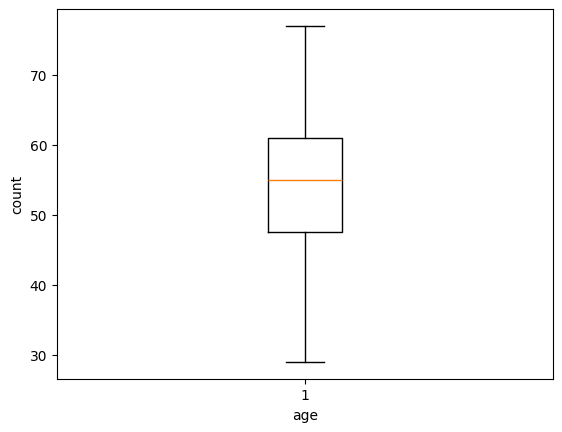

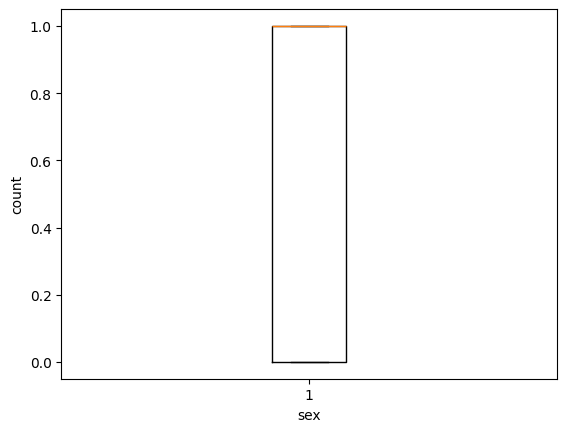

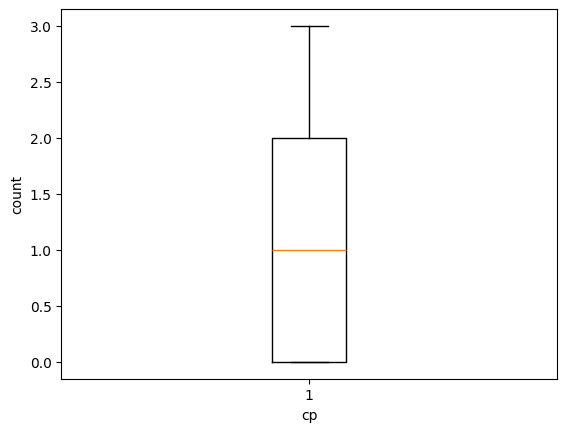

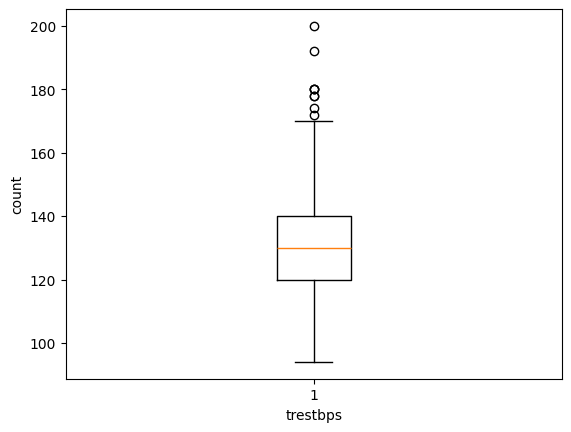

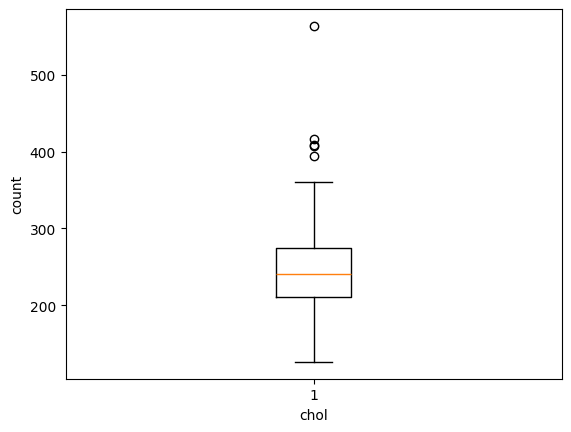

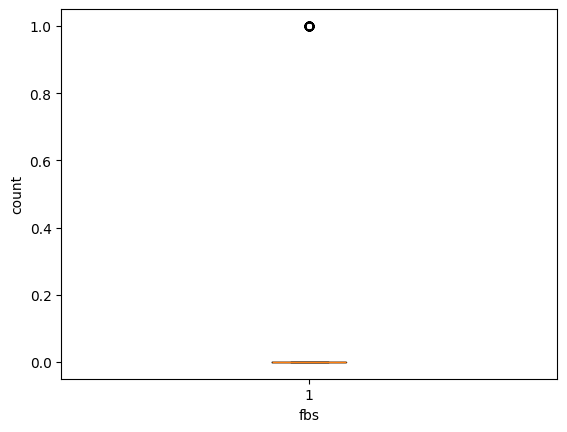

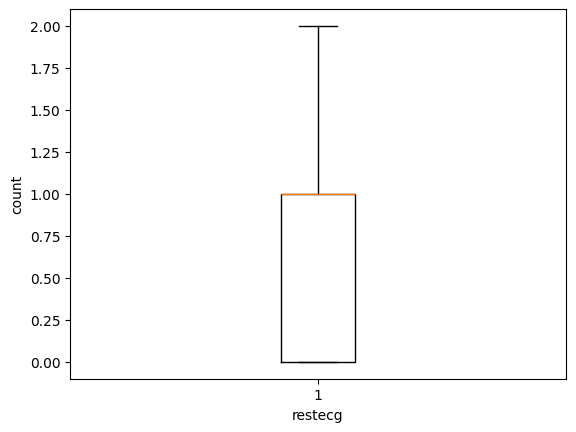

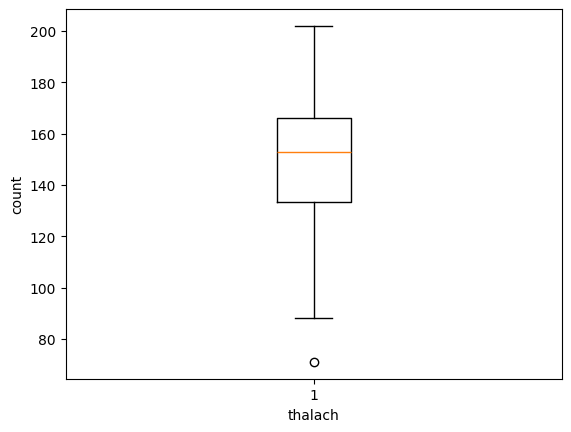

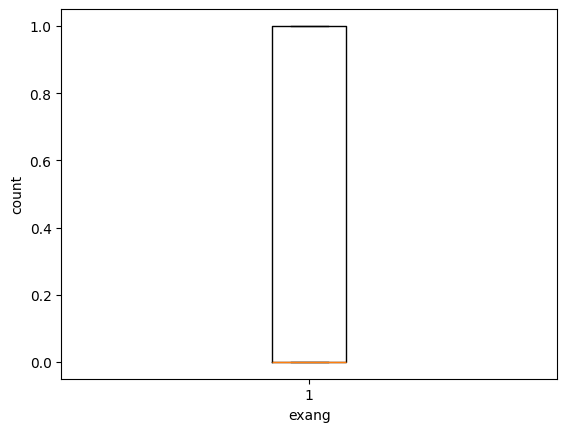

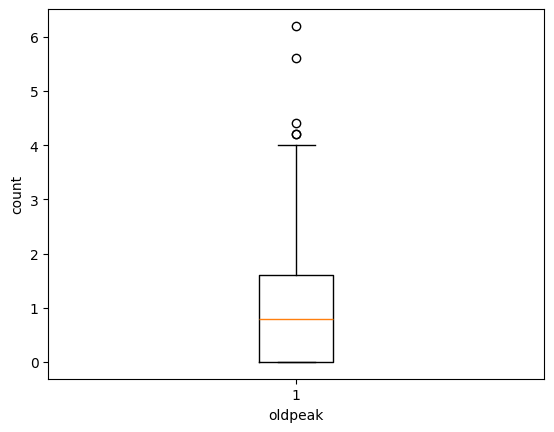

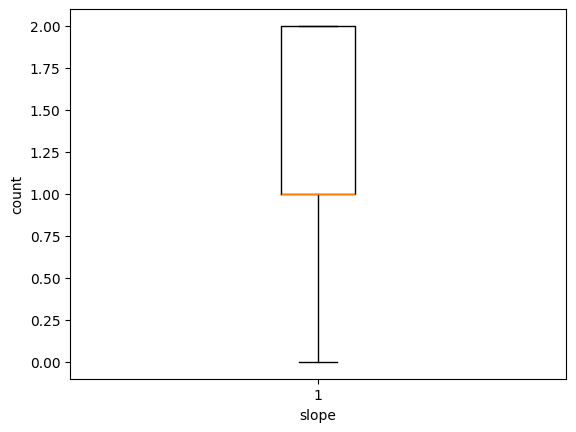

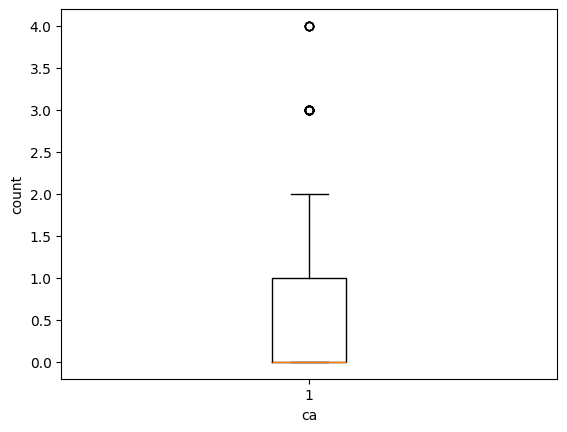

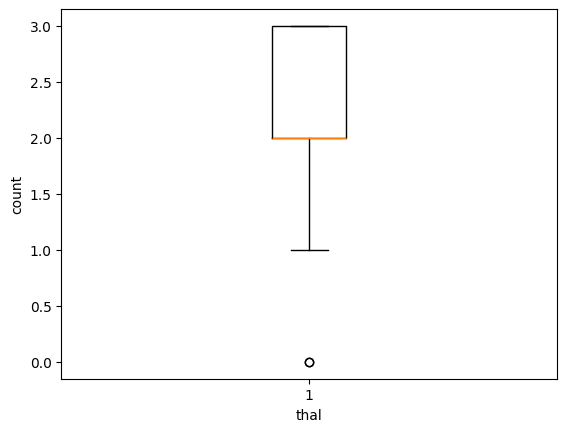

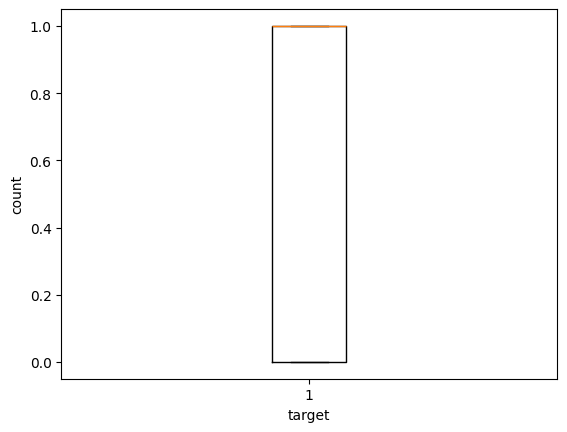

In [ ]:
for i in col:
  if heart[i].dtypes==object:
    pass
  else:
    plt.boxplot(heart[i])
    plt.xlabel(i)
    plt.ylabel('count')
    plt.show()

In [ ]:
numeric_cols =  heart.dtypes[heart.dtypes != 'object'].index

for col in numeric_cols:
    Q1 = heart[col].quantile(0.25)
    Q3 = heart[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = heart[(heart[col] < lower) | (heart[col] > upper)]

    print(col)
    print("Lower:", lower)
    print("Upper:", upper)
    print("Outliers:", len(outliers))
    print()

age
Lower: 27.25
Upper: 81.25
Outliers: 0

sex
Lower: -1.5
Upper: 2.5
Outliers: 0

cp
Lower: -3.0
Upper: 5.0
Outliers: 0

trestbps
Lower: 90.0
Upper: 170.0
Outliers: 9

chol
Lower: 115.75
Upper: 369.75
Outliers: 5

fbs
Lower: 0.0
Upper: 0.0
Outliers: 45

restecg
Lower: -1.5
Upper: 2.5
Outliers: 0

thalach
Lower: 84.75
Upper: 214.75
Outliers: 1

exang
Lower: -1.5
Upper: 2.5
Outliers: 0

oldpeak
Lower: -2.4000000000000004
Upper: 4.0
Outliers: 5

slope
Lower: -0.5
Upper: 3.5
Outliers: 0

ca
Lower: -1.5
Upper: 2.5
Outliers: 25

thal
Lower: 0.5
Upper: 4.5
Outliers: 2

target
Lower: -1.5
Upper: 2.5
Outliers: 0



In [ ]:
heart.corr(numeric_only=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
col_list=[]
for i in heart.columns:
    if((heart[i].dtype!='object')&(i!='target')):
        col_list.append(i)

In [ ]:
col_list

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

In [ ]:
x=heart[col_list]
vif_data=pd.DataFrame()
vif_data['feature']=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

     feature        VIF
0        age  38.998305
1        sex   3.523211
2         cp   2.414403
3   trestbps  58.557335
4       chol  26.267365
5        fbs   1.268205
6    restecg   2.058206
7    thalach  42.742178
8      exang   2.022527
9    oldpeak   3.062890
10     slope  10.072734
11        ca   1.808925
12      thal  17.165303


In [ ]:
heart.drop('age',axis=1,inplace=True)

In [ ]:
col_list=[]
for i in heart.columns:
    if((heart[i].dtype!='object')&(i!='target')):
        col_list.append(i)

x=heart[col_list]
vif_data=pd.DataFrame()
vif_data['feature']=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

     feature        VIF
0        sex   3.523210
1         cp   2.409683
2   trestbps  42.943607
3       chol  23.632837
4        fbs   1.267435
5    restecg   2.053256
6    thalach  42.561820
7      exang   2.022140
8    oldpeak   3.043370
9      slope  10.016331
10        ca   1.750197
11      thal  16.936385


In [ ]:
heart.drop('cp',axis=1,inplace=True)

In [ ]:
col_list=[]
for i in heart.columns:
    if((heart[i].dtype!='object')&(i!='target')):
        col_list.append(i)

x=heart[col_list]
vif_data=pd.DataFrame()
vif_data['feature']=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

     feature        VIF
0        sex   3.521046
1   trestbps  42.472682
2       chol  23.579535
3        fbs   1.250788
4    restecg   2.052170
5    thalach  41.159535
6      exang   1.824952
7    oldpeak   3.042839
8      slope  10.013842
9         ca   1.719732
10      thal  16.847200


In [ ]:
heart.drop('trestbps',axis=1,inplace=True)

In [ ]:
col_list=[]
for i in heart.columns:
    if((heart[i].dtype!='object')&(i!='target')):
        col_list.append(i)

x=heart[col_list]
vif_data=pd.DataFrame()
vif_data['feature']=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

   feature        VIF
0      sex   3.519588
1     chol  20.862244
2      fbs   1.215546
3  restecg   2.050006
4  thalach  30.046270
5    exang   1.794655
6  oldpeak   2.850703
7    slope   9.962689
8       ca   1.710732
9     thal  16.318130


In [ ]:
heart.drop('chol',axis=1,inplace=True)

In [ ]:
col_list=[]
for i in heart.columns:
    if((heart[i].dtype!='object')&(i!='target')):
        col_list.append(i)

x=heart[col_list]
vif_data=pd.DataFrame()
vif_data['feature']=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

   feature        VIF
0      sex   3.371741
1      fbs   1.214067
2  restecg   2.031041
3  thalach  20.929981
4    exang   1.735560
5  oldpeak   2.768780
6    slope   9.820129
7       ca   1.691997
8     thal  15.069494


In [ ]:
heart.drop('thalach',axis=1,inplace=True)

In [ ]:
col_list=[]
for i in heart.columns:
    if((heart[i].dtype!='object')&(i!='target')):
        col_list.append(i)

x=heart[col_list]
vif_data=pd.DataFrame()
vif_data['feature']=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

   feature        VIF
0      sex   3.335674
1      fbs   1.187552
2  restecg   1.996184
3    exang   1.702266
4  oldpeak   2.592035
5    slope   5.857049
6       ca   1.663956
7     thal  10.272194


In [ ]:
heart.drop('thal',axis=1,inplace=True)

In [ ]:
col_list=[]
for i in heart.columns:
    if((heart[i].dtype!='object')&(i!='target')):
        col_list.append(i)

x=heart[col_list]
vif_data=pd.DataFrame()
vif_data['feature']=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

   feature       VIF
0      sex  3.001986
1      fbs  1.184029
2  restecg  1.941842
3    exang  1.621540
4  oldpeak  1.971941
5    slope  3.093044
6       ca  1.649937


In [ ]:
heart.describe()

,sex,fbs,restecg,exang,oldpeak,slope,ca,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,0.683168,0.148515,0.528053,0.326733,1.039604,1.399340,0.729373,0.544554
std,0.466011,0.356198,0.525860,0.469794,1.161075,0.616226,1.022606,0.498835
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,0.800000,1.000000,0.000000,1.000000
75%,1.000000,0.000000,1.000000,1.000000,1.600000,2.000000,1.000000,1.000000
max,1.000000,1.000000,2.000000,1.000000,6.200000,2.000000,4.000000,1.000000


In [ ]:
x=pd.DataFrame(heart[vif_data.feature])
x

,sex,fbs,restecg,exang,oldpeak,slope,ca
0,1,1,0,0,2.3,0,0
1,1,0,1,0,3.5,0,0
2,0,0,0,0,1.4,2,0
3,1,0,1,0,0.8,2,0
4,0,0,1,1,0.6,2,0
...,...,...,...,...,...,...,...
298,0,0,1,1,0.2,1,0
299,1,0,1,0,1.2,1,0
300,1,1,1,0,3.4,1,2
301,1,0,1,1,1.2,1,1


In [ ]:
y=heart['target']
y

,target
0,1
1,1
2,1
3,1
4,1
...,...
298,0
299,0
300,0
301,0


In [ ]:
x.columns

Index(['sex', 'fbs', 'restecg', 'exang', 'oldpeak', 'slope', 'ca'], dtype='object')

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logmodel=LogisticRegression()

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(242, 7)
(61, 7)
(242,)
(61,)


In [ ]:
logmodel.fit(x_train,y_train)
prediction = logmodel.predict(x_test)

In [ ]:
prediction


array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
y_test

,target
179,0
228,0
111,1
246,0
60,1
...,...
249,0
104,1
300,0
193,0


In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [ ]:
accuracy_score(y_test,prediction)

0.8032786885245902

In [ ]:
confusion_matrix(y_test,prediction)

array([[25,  4],
       [ 8, 24]])

In [ ]:
#accuracy

#TP+TN/everything


a=(25+24)/(25+8+24+4)

In [ ]:
a

0.8032786885245902